In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from csan import (
    make_synth_blocks,
    build_local_pool_matrix_from_grid,
    validity_first_backtest,
    load_eobs_rr,
    eobs_to_blocks,
    basic_X_diagnostics)



### Import data

In [2]:
# Choose threshold for triggering
u = 40.

# Data parameters
# region + resolution choices (edit these per experiment)
# E-OBS extraction / block construction
lat_slice = (40, 50) #(45, 55)
lon_slice = (5, 12) #(0, 15)
coarsen = (1,1)

# parametric trigger setup
months = [10, 11, 12, 1, 2, 3]
payout = 1.0

path = "e-obs-data/rr_ens_mean_0.25deg_reg_v31.0e.nc"

rr_small = load_eobs_rr(path, lat_slice=lat_slice, lon_slice=lon_slice, coarsen=coarsen, 
    chunks={"time": 365},
    # year_range=(1950, 2000)
    )
X_np, years, grid_shape, peer_coords = eobs_to_blocks(rr_small, u=u, months=months, payout=payout)

basic_X_diagnostics(X_np)
print("years:", years.min(), "to", years.max())
print("grid_shape:", grid_shape, "n:", X_np.shape[1])

[X] shape: (75, 1120), zero frac: 0.775
[X] total loss per block: mean=478, median=474, p95/p99/max: 884/1.05e+03/1.16e+03
years: 1950 to 2024
grid_shape: (40, 28) n: 1120


In [3]:
# X_np, years, grid_shape, peer_coords = make_synth_blocks(
#     B=400, grid_shape=(12,12),
#     p_event=1., p_hit_given_event=.1,
#     severity="pareto", pareto_alpha=1.8, pareto_scale=1.0,
#     heterogeneity=.4,
#     common_factor_strength=0.,
#     spatial_factor_strength=0.,
#     seed=0,
# )
# print(X_np.shape, years.min(), years.max(), grid_shape, peer_coords.shape)

hit_rate_per_peer = (X_np > 0).mean(axis=0)      # length n
print("avg peer hit rate:", hit_rate_per_peer.mean())
print("min/median/max peer hit rate:", hit_rate_per_peer.min(),
      np.median(hit_rate_per_peer), hit_rate_per_peer.max())

avg peer hit rate: 0.22483333333333333
min/median/max peer hit rate: 0.0 0.10666666666666667 1.0


### Set model parameters

In [4]:
delta=0.1
eta=0.0
eps=0.2


### Split mode: random
#### Global vs Local pooling

=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: random | Splits: 50 | nTest=5 | nC=35
Nominal coverage: 0.900
PASS rate: 0.980

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.919, std=0.071
  operational: mean=0.919, std=0.071
  identity  : mean=0.972, std=0.013

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.872 (shortfall=0.028), p05=0.896 (shortfall=0.004)
  operational : worst=0.872 (shortfall=0.028), p05=0.896 (shortfall=0.004)
  identity    : worst=0.904 (shortfall=0.000), p05=0.932 (shortfall=0.000)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.29 ± 0.0708
  mean <w,c*> (candidate)    : 0.928 ± 0.0614
  mean <w,c_op> (operational): 0.936 ± 0.0774
  AggCapRatio candidate      : 0.720 ± 0.026
  AggCapRatio operational    : 0.726 ± 0.047

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.

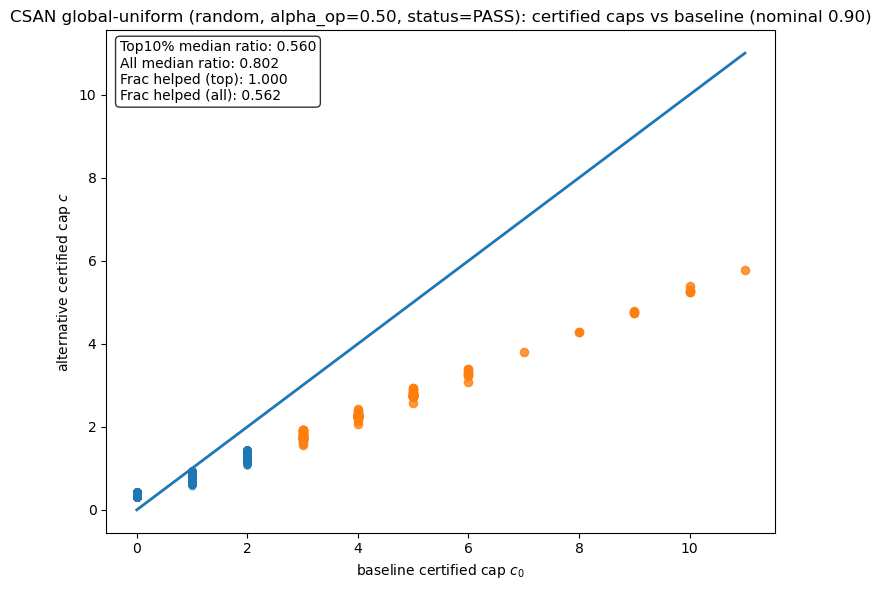

=== Validity-first backtest (updated) ===
Pooling: local
Mode: random | Splits: 50 | nTest=5 | nC=35
Nominal coverage: 0.900
PASS rate: 1.000

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.946, std=0.024
  operational: mean=0.946, std=0.024
  identity  : mean=0.972, std=0.013

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.880 (shortfall=0.020), p05=0.904 (shortfall=0.000)
  operational : worst=0.880 (shortfall=0.020), p05=0.904 (shortfall=0.000)
  identity    : worst=0.904 (shortfall=0.000), p05=0.932 (shortfall=0.000)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.29 ± 0.0708
  mean <w,c*> (candidate)    : 1.15 ± 0.0746
  mean <w,c_op> (operational): 1.15 ± 0.0746
  AggCapRatio candidate      : 0.895 ± 0.012
  AggCapRatio operational    : 0.895 ± 0.012

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.695 ± 0.022

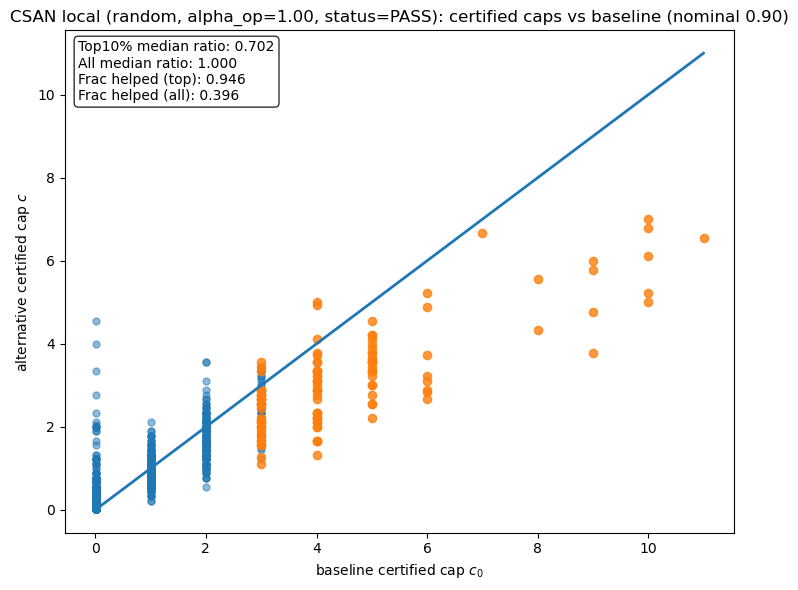

In [5]:
W_local = build_local_pool_matrix_from_grid(grid_shape, radius=1, include_self=True)
# W_local = build_local_pool_matrix_from_coords(peer_coords, k=5, include_self=True)

# - global: W_local=None
# - local:  pass your neighborhood W_local
res_global_rand = validity_first_backtest(X_np, years, delta=delta, eta=eta, eps=eps,
                                         split_mode="random", n_splits=50,
                                         nT = 20, nV=15, nC=35, nTest=5, W_local=None, make_plots=False,
                                         relief_scatter=True, relief_scatter_pick="random_top10")

res_local_rand  = validity_first_backtest(X_np, years, delta=delta, eta=eta, eps=eps,
                                         split_mode="random", n_splits=50,
                                         nT = 20, nV=15, nC=35, nTest=5, W_local=W_local, make_plots=False,
                                         relief_scatter=True,  relief_scatter_pick="random_top10")


### Split mode: time
#### Global vs Local pooling

=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: time | Splits: 6 | nTest=5 | nC=45
Nominal coverage: 0.900
PASS rate: 1.000

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.786, std=0.079
  operational: mean=0.786, std=0.079
  identity  : mean=0.949, std=0.010

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.267 (shortfall=0.633), p05=0.633 (shortfall=0.267)
  operational : worst=0.267 (shortfall=0.633), p05=0.633 (shortfall=0.267)
  identity    : worst=0.367 (shortfall=0.533), p05=0.733 (shortfall=0.167)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.27 ± 0.025
  mean <w,c*> (candidate)    : 0.974 ± 0.0203
  mean <w,c_op> (operational): 0.974 ± 0.0203
  AggCapRatio candidate      : 0.766 ± 0.009
  AggCapRatio operational    : 0.766 ± 0.009

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.581 

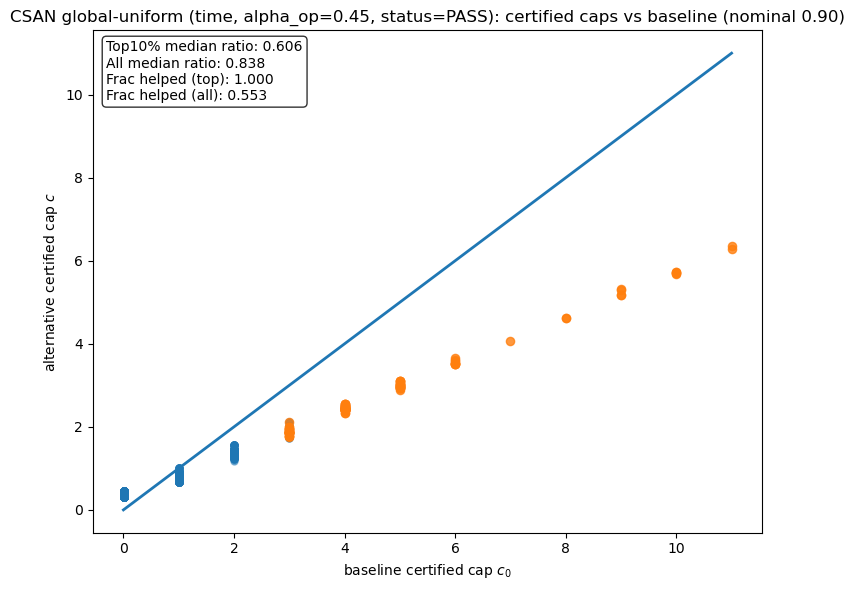

=== Validity-first backtest (updated) ===
Pooling: local
Mode: time | Splits: 6 | nTest=5 | nC=45
Nominal coverage: 0.900
PASS rate: 1.000

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.901, std=0.023
  operational: mean=0.901, std=0.023
  identity  : mean=0.949, std=0.010

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.433 (shortfall=0.467), p05=0.633 (shortfall=0.267)
  operational : worst=0.433 (shortfall=0.467), p05=0.633 (shortfall=0.267)
  identity    : worst=0.367 (shortfall=0.533), p05=0.733 (shortfall=0.167)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.27 ± 0.025
  mean <w,c*> (candidate)    : 1.13 ± 0.0316
  mean <w,c_op> (operational): 1.13 ± 0.0316
  AggCapRatio candidate      : 0.891 ± 0.008
  AggCapRatio operational    : 0.891 ± 0.008

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.686 ± 0.013
  T

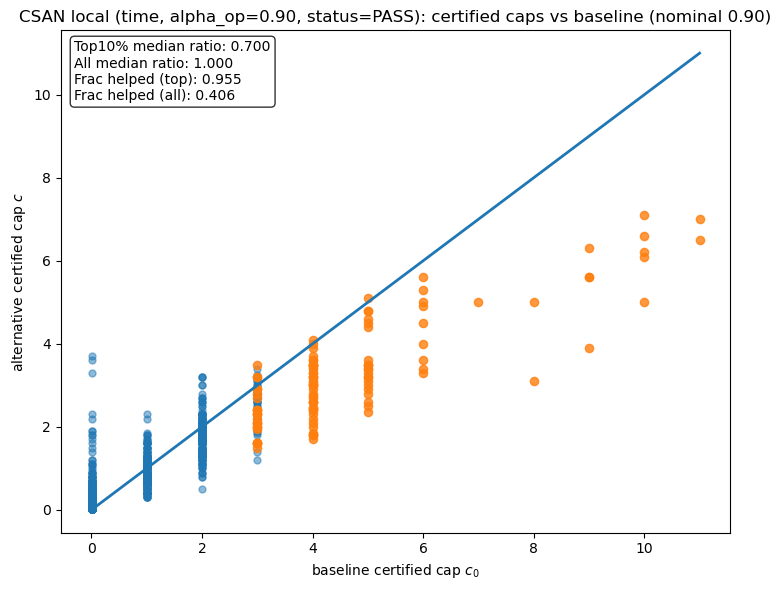

In [6]:
W_local = build_local_pool_matrix_from_grid(grid_shape, radius=1, include_self=True)
# W_local = build_local_pool_matrix_from_coords(peer_coords, k=5, include_self=True)

# - global: W_local=None
# - local:  pass your neighborhood W_local
res_global_time = validity_first_backtest(X_np, years, delta=delta, eta=eta, eps=eps,
                                         split_mode="time",
                                         nT = 10, nV=10, nC=45, nTest=5, W_local=None, make_plots=False, 
                                         relief_scatter=True, relief_scatter_pick="random_top10")

res_local_time  = validity_first_backtest(X_np, years, delta=delta, eta=eta, eps=eps,
                                         split_mode="time",
                                         nT = 10, nV=10, nC=45, nTest=5, W_local=W_local, make_plots=False,
                                         relief_scatter=True,  relief_scatter_pick="random_top10")

### Save results

In [7]:
from csan import print_latex_row, print_latex_identity_row
# ============================================================
# E-OBS: Print LaTeX tables from results
# ============================================================

# --- Random splits ---
print_latex_row(res_global_rand, "Global")
print_latex_row(res_local_rand, "Local")
print_latex_identity_row(res_global_rand)

print()

# --- Time splits ---
print_latex_row(res_global_time, "Global")
print_latex_row(res_local_time, "Local")
print_latex_identity_row(res_global_time)


Global & 0.98 & 0.56\tiny$\pm$0.10 & 0.919 (0.896) & 0.726\tiny$\pm$0.047 & 0.506\tiny$\pm$0.087 \\
Local & 1.00 & 1.00\tiny$\pm$0.00 & 0.946 (0.904) & 0.895\tiny$\pm$0.012 & 0.695\tiny$\pm$0.022 \\
Identity & -- & 0 & 0.972 (0.932) & -- & -- \\

Global & 1.00 & 0.47\tiny$\pm$0.03 & 0.786 (0.633) & 0.766\tiny$\pm$0.009 & 0.581\tiny$\pm$0.020 \\
Local & 1.00 & 0.98\tiny$\pm$0.04 & 0.901 (0.633) & 0.891\tiny$\pm$0.008 & 0.686\tiny$\pm$0.013 \\
Identity & -- & 0 & 0.949 (0.733) & -- & -- \\


### Check sensitivity to calibration window in nonstationary setting

In [8]:
W_local = build_local_pool_matrix_from_grid(grid_shape, radius=1, include_self=True)
# W_local = build_local_pool_matrix_from_coords(peer_coords, k=5, include_self=True)

W = 60
nC_list = [10, 20, 30, 40, 50]

In [9]:
#  ---- Time splits ----
res_global_time_nc = {}
res_local_time_nc = {}

for nC in nC_list:
    nT = int((W - nC) / 2)
    nV = nT
    res_global_time_nc[nC] = validity_first_backtest(
        X_np, years, delta=delta, eta=eta, eps=eps,
        split_mode="time",
        nT=nT, nV=nV, nC=nC, nTest=5, W_local=None,
        make_plots=False)

for nC in nC_list:
    nT = int((W - nC) / 2)
    nV = nT
    res_local_time_nc[nC] = validity_first_backtest(
        X_np, years, delta=delta, eta=eta, eps=eps,
        split_mode="time",
        nT=nT, nV=nV, nC=nC, nTest=5, W_local=W_local,
        make_plots=False)


=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: time | Splits: 11 | nTest=5 | nC=10
Nominal coverage: 0.900
PASS rate: 0.909

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.868, std=0.100
  operational: mean=0.868, std=0.100
  identity  : mean=0.957, std=0.016

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.582 (shortfall=0.318), p05=0.745 (shortfall=0.155)
  operational : worst=0.600 (shortfall=0.300), p05=0.745 (shortfall=0.155)
  identity    : worst=0.727 (shortfall=0.173), p05=0.836 (shortfall=0.064)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.54 ± 0.155
  mean <w,c*> (candidate)    : 1.01 ± 0.138
  mean <w,c_op> (operational): 1.05 ± 0.207
  AggCapRatio candidate      : 0.653 ± 0.034
  AggCapRatio operational    : 0.680 ± 0.106

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.387 ± 0

### Check sensitivity to calibration window in random splits setting

In [10]:
# ---- Random splits ----
res_global_rand_nc = {}
res_local_rand_nc = {}

for nC in nC_list:
    nT = int((W - nC) / 2)
    nV = nT
    res_global_rand_nc[nC] = validity_first_backtest(
        X_np, years, delta=delta, eta=eta, eps=eps,
        split_mode="random", n_splits=50,
        nT=nT, nV=nV, nC=nC, nTest=5, W_local=None,
        make_plots=False)
    s = res_global_rand_nc[nC]["peer_cov_summary_identity"]

print("================================================")

for nC in nC_list:
    nT = int((W - nC) / 2)
    nV = nT
    res_local_rand_nc[nC] = validity_first_backtest(
        X_np, years, delta=delta, eta=eta, eps=eps,
        split_mode="random", n_splits=50,
        nT=nT, nV=nV, nC=nC, nTest=5, W_local=W_local,
        make_plots=False)

=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: random | Splits: 50 | nTest=5 | nC=10
Nominal coverage: 0.900
PASS rate: 0.940

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.878, std=0.110
  operational: mean=0.883, std=0.110
  identity  : mean=0.962, std=0.016

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.816 (shortfall=0.084), p05=0.852 (shortfall=0.048)
  operational : worst=0.824 (shortfall=0.076), p05=0.856 (shortfall=0.044)
  identity    : worst=0.856 (shortfall=0.044), p05=0.904 (shortfall=0.000)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.38 ± 0.138
  mean <w,c*> (candidate)    : 0.946 ± 0.114
  mean <w,c_op> (operational): 0.973 ± 0.164
  AggCapRatio candidate      : 0.687 ± 0.035
  AggCapRatio operational    : 0.706 ± 0.082

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.480

### Test allocation A fitted using VO-DS 

row sums: 0.99999994 1.0 1.0000001
col sums: 0.99999845 1.0 1.0000013
min entry: 0.000546234 max entry: 0.0014457277
[split 0] VO objective: J(I)=788.8 J(U)=53.44 J(A_bar)=53.45  min_J_over_alphas=53.45 at alpha=1.00
row sums: 0.9999999 1.0 1.0000001
col sums: 0.99999875 1.0 1.0000012
min entry: 0.0005238416 max entry: 0.0013913483
row sums: 0.99999994 1.0 1.0000001
col sums: 0.9999984 1.0 1.0000013
min entry: 0.00054029597 max entry: 0.0014764979
row sums: 0.9999999 1.0 1.0000001
col sums: 0.99999875 1.0 1.0000014
min entry: 0.00055153 max entry: 0.0015048651
row sums: 0.9999999 1.0 1.0000001
col sums: 0.99999845 1.0 1.0000015
min entry: 0.00054060516 max entry: 0.0014729782
row sums: 0.9999999 1.0 1.0000001
col sums: 0.9999986 1.0 1.0000014
min entry: 0.00055323227 max entry: 0.0014475415
row sums: 0.9999999 1.0 1.0000001
col sums: 0.99999857 1.0 1.0000013
min entry: 0.0005365468 max entry: 0.0014497234
row sums: 0.9999999 1.0 1.0000001
col sums: 0.99999887 1.0 1.0000012
min entry: 0

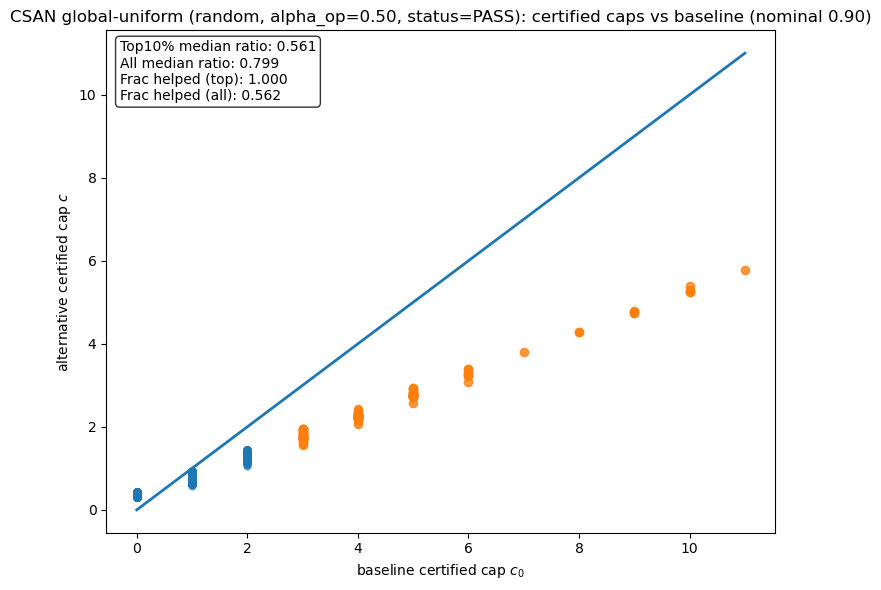

In [11]:
bt_VO_DS = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=eps,
    alphas=np.linspace(0,1,51, dtype=np.float32),
    nT = 20, nV=15, nC=35, nTest=5,
    split_mode="random", n_splits=50,
    make_plots=False,
    use_vo_Abar=True,
    relief_scatter=True,
    relief_scatter_pick = "first_pass",  # "first_pass" | "median_top10" | "best_top10"
)


In [12]:
print_latex_row(bt_VO_DS, r"VO-DS")


VO-DS & 0.98 & 0.57\tiny$\pm$0.10 & 0.919 (0.896) & 0.718\tiny$\pm$0.047 & 0.493\tiny$\pm$0.088 \\


## Export data

In [13]:
from csan import print_nc_table
# ---- Print time-split nC table ----
print("% ===================== E-OBS TIME SPLITS nC SENSITIVITY =====================")
print_nc_table(
    res_global_time_nc, res_local_time_nc, nC_list,
    caption=r"E-OBS time-ordered splits, varying $n_C$ "
            r"($n_{\mathrm{test}}\!=\!5$). Coverage is empirical "
            r"(not theorem-aligned). Fr$<$.9: fraction of agents below nominal.",
    label="tab:eobs_time_nc",
)

print()

# ---- Print random-split nC table ----
print("% ===================== E-OBS RANDOM SPLITS nC SENSITIVITY =====================")
print_nc_table(
    res_global_rand_nc, res_local_rand_nc, nC_list,
    caption=r"E-OBS random splits, varying $n_C$ "
            r"($n_{\mathrm{test}}\!=\!5$, 50 splits). "
            r"Fr$<$.9: fraction of agents below nominal.",
    label="tab:eobs_rand_nc",
)

% ===================== E-OBS TIME SPLITS nC SENSITIVITY =====================
\multirow{5}{*}{\rotatebox{90}{\tiny Global}} & 10 & 0.91 & 0.868 & 0.745 & 0.600 & 0.836 \\
 & 20 & 0.91 & 0.800 & 0.709 & 0.509 & 0.796 \\
 & 30 & 1.00 & 0.756 & 0.600 & 0.491 & 0.874 \\
 & 40 & 1.00 & 0.762 & 0.600 & 0.400 & 0.820 \\
 & 50 & 1.00 & 0.742 & 0.564 & 0.345 & 0.854 \\
\midrule
\multirow{5}{*}{\rotatebox{90}{\tiny Local}} & 10 & 1.00 & 0.919 & 0.782 & 0.545 & 0.333 \\
 & 20 & 1.00 & 0.908 & 0.727 & 0.545 & 0.383 \\
 & 30 & 1.00 & 0.893 & 0.691 & 0.527 & 0.411 \\
 & 40 & 1.00 & 0.882 & 0.618 & 0.473 & 0.429 \\
 & 50 & 1.00 & 0.868 & 0.600 & 0.382 & 0.466 \\

% ===================== E-OBS RANDOM SPLITS nC SENSITIVITY =====================
\multirow{5}{*}{\rotatebox{90}{\tiny Global}} & 10 & 0.94 & 0.883 & 0.856 & 0.824 & 0.848 \\
 & 20 & 0.98 & 0.890 & 0.864 & 0.848 & 0.808 \\
 & 30 & 0.88 & 0.895 & 0.868 & 0.840 & 0.797 \\
 & 40 & 1.00 & 0.884 & 0.860 & 0.832 & 0.854 \\
 & 50 & 0.96 & 0.885 & 0

In [14]:
from csan import print_identity_nc_table
# ============================================================
# Print identity baseline nC sensitivity tables
# Uses results already computed in the nC sweep dicts
# ============================================================

nC_list = [10, 20, 30, 40, 50]

# ---- Time splits ----
print("% ===================== IDENTITY TIME SPLITS nC =====================")
print_identity_nc_table(
    res_global_time_nc, nC_list,
    caption=r"Identity baseline under time-ordered splits on E-OBS. "
            r"Coverage degrades with $n_C$ due to nonstationarity, "
            r"confirming that drift affects all methods equally.",
    label="tab:eobs_identity_time",
)

print()

# ---- Random splits ----
print("% ===================== IDENTITY RANDOM SPLITS nC =====================")
print_identity_nc_table(
    res_global_rand_nc, nC_list,
    caption=r"Identity baseline under random splits on E-OBS. "
            r"Coverage remains above nominal across all $n_C$, "
            r"confirming conformal validity under exchangeability.",
    label="tab:eobs_identity_rand",
)

% ===================== IDENTITY TIME SPLITS nC =====================
10 & 0.957 & 0.836 & 0.727 & 0.129 \\
20 & 0.952 & 0.818 & 0.618 & 0.182 \\
30 & 0.945 & 0.782 & 0.527 & 0.203 \\
40 & 0.939 & 0.764 & 0.509 & 0.222 \\
50 & 0.931 & 0.727 & 0.491 & 0.252 \\

% ===================== IDENTITY RANDOM SPLITS nC =====================
10 & 0.962 & 0.904 & 0.856 & 0.047 \\
20 & 0.962 & 0.904 & 0.876 & 0.043 \\
30 & 0.961 & 0.904 & 0.876 & 0.049 \\
40 & 0.961 & 0.904 & 0.856 & 0.047 \\
50 & 0.960 & 0.900 & 0.860 & 0.051 \\
